# Tarea final - Máquinas de Soporte Vectorial

**Base:** `breast_cancer.csv`  
**Objetivo:** desarrollar un clasificador mediante Máquinas de Soporte Vectorial para predecir si el diagnóstico corresponde a un tumor benigno o maligno, usando atributos de composición del núcleo de células mamarias.

La solución sigue lo trabajado en la clase: preparación de datos, estandarización, `Pipeline`, `SVC`, validación cruzada con `GridSearchCV`, evaluación hold-out y revisión de overlap entre atributos.

## Ejercicio 1: Preparar el ambiente de trabajo

Se importan las librerías, se ajustan parámetros gráficos, se carga la base, se eliminan `id` y `Unnamed: 32`, y se recodifica `diagnosis` a formato numérico.

Criterio usado para la recodificación:

- `B` = 0: benigno.
- `M` = 1: maligno.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pickle

# Parámetros gráficos solicitados en la tarea.
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

RANDOM_STATE = 11238

In [2]:
# Carga de la base de datos.
df_raw = pd.read_csv('breast_cancer.csv')

print('Dimensiones originales:', df_raw.shape)
df_raw.head()

Dimensiones originales: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Eliminación de columnas que no deben ingresar al modelo.
cols_to_drop = [col for col in ['id', 'Unnamed: 32'] if col in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop).copy()

# Recodificación del vector objetivo.
df['diagnosis_bin'] = df['diagnosis'].map({'B': 0, 'M': 1}).astype(int)

print('Columnas eliminadas:', cols_to_drop)
print('Dimensiones depuradas:', df.shape)
print('\nDistribución del vector objetivo original:')
print(df['diagnosis'].value_counts())
print('\nDistribución del vector objetivo recodificado:')
print(df['diagnosis_bin'].value_counts())

df.head()

Columnas eliminadas: ['id', 'Unnamed: 32']
Dimensiones depuradas: (569, 32)

Distribución del vector objetivo original:
diagnosis
B    357
M    212
Name: count, dtype: int64

Distribución del vector objetivo recodificado:
diagnosis_bin
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_bin
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [4]:
# Matriz de atributos y vector objetivo.
features = [col for col in df.columns if col not in ['diagnosis', 'diagnosis_bin']]
X = df[features]
y = df['diagnosis_bin']

print('Cantidad de atributos predictivos:', len(features))
print(features)

Cantidad de atributos predictivos: 30
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


## Ejercicio 2: Visualizando la distribución de los atributos

Para cada atributo se grafican histogramas condicionales según la clase del diagnóstico. Además, se agregan líneas verticales con la media de cada clase. Cuando las distribuciones de ambas clases se superponen mucho, el atributo tiene menor capacidad individual para separar benignos y malignos.

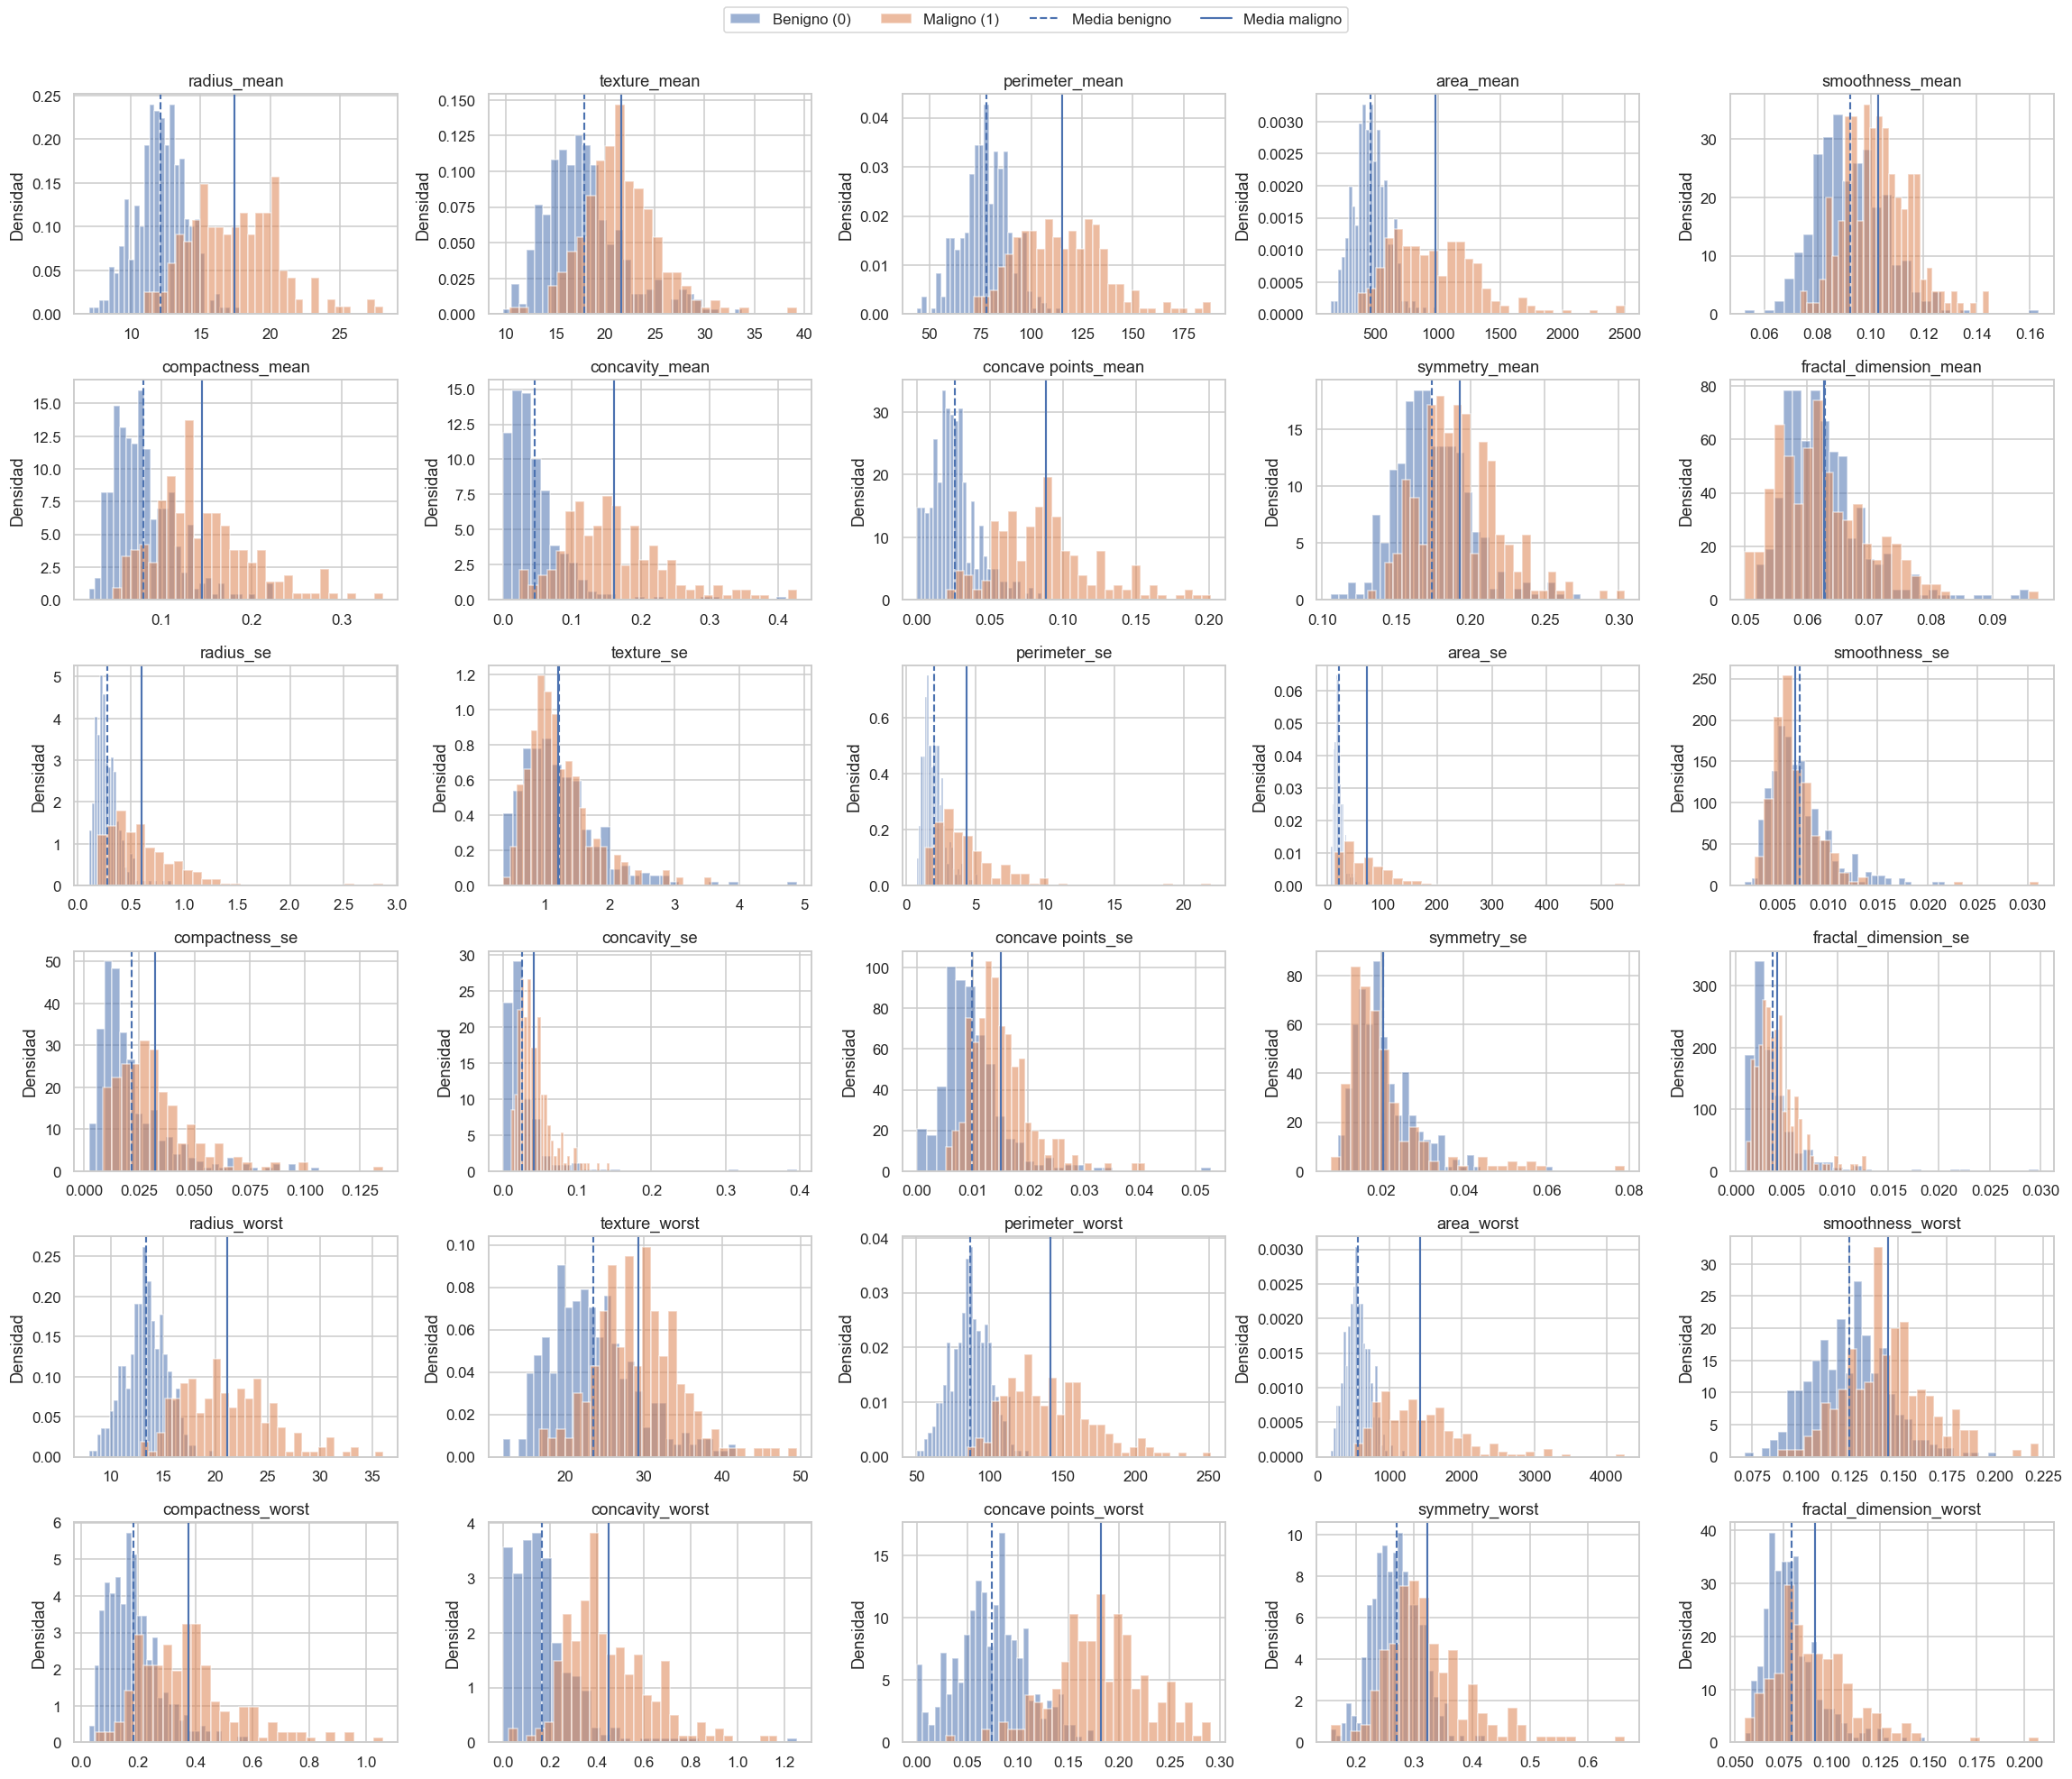

In [5]:
def plot_conditional_histograms(dataframe, attributes, target='diagnosis_bin', cols=5, bins=30):
    """
    Grafica histogramas condicionales por clase para todos los atributos solicitados.
    Incluye líneas verticales con la media de cada clase.
    """
    rows = int(np.ceil(len(attributes) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.0))
    axes = np.array(axes).reshape(-1)

    for ax, attribute in zip(axes, attributes):
        benign = dataframe.loc[dataframe[target] == 0, attribute]
        malignant = dataframe.loc[dataframe[target] == 1, attribute]

        ax.hist(benign, bins=bins, alpha=0.55, density=True, label='Benigno (0)')
        ax.hist(malignant, bins=bins, alpha=0.55, density=True, label='Maligno (1)')

        ax.axvline(benign.mean(), linestyle='--', linewidth=1.4, label='Media benigno')
        ax.axvline(malignant.mean(), linestyle='-', linewidth=1.4, label='Media maligno')

        ax.set_title(attribute)
        ax.set_xlabel('')
        ax.set_ylabel('Densidad')

    for ax in axes[len(attributes):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_conditional_histograms(df, features, target='diagnosis_bin', cols=5, bins=30)

**Comentario general.** Visualmente, varios atributos asociados al tamaño y forma del núcleo celular separan mejor ambas clases, especialmente medidas `worst` y variables como radio, perímetro, área, concavidad y puntos cóncavos. En cambio, variables como dimensión fractal, suavidad, simetría y algunas medidas de error estándar tienden a mostrar mayor similitud entre clases.

## Ejercicio 3: Estimando el porcentaje de overlap en los atributos

El overlap mide la comunalidad entre las distribuciones condicionales de las clases. Un valor más alto indica mayor superposición entre benignos y malignos; por lo tanto, el atributo separa peor las clases por sí solo. Un valor bajo indica mayor capacidad discriminante individual.

In [6]:
def histogram_overlap(df, attribute, target, perc=100):
    """
    Estima la intersección entre los histogramas condicionales de un atributo.
    Valores altos indican mayor overlap o comunalidad entre clases.
    """
    # get lower bound
    empirical_lower_bound = np.floor(df[attribute].min())
    # get upper bound
    empirical_upper_bound = np.ceil(df[attribute].max())

    if empirical_lower_bound == empirical_upper_bound:
        empirical_upper_bound += 1

    # preserve histograms
    tmp_hist_holder = dict()
    # for each target class
    for unique_value in np.unique(df[target]):
        # get histogram
        tmp, _ = np.histogram(
            # for a specific attribute
            df[df[target] == unique_value][attribute],
            # define percentage
            bins=perc,
            # limit empirical range for comparison
            range=[empirical_lower_bound, empirical_upper_bound]
        )
        # append to dict
        tmp_hist_holder['h_' + str(unique_value)] = tmp

    get_minima = np.minimum(tmp_hist_holder['h_1'], tmp_hist_holder['h_0'])
    intersection = np.true_divide(np.sum(get_minima), np.sum(tmp_hist_holder['h_0']))
    return intersection

In [7]:
overlap_df = pd.DataFrame({
    'attribute': features,
    'overlap': [histogram_overlap(df, col, 'diagnosis_bin', perc=100) for col in features]
}).sort_values('overlap', ascending=False).reset_index(drop=True)

overlap_df.to_csv('overlap_atributos_svm.csv', index=False)

overlap_df

,attribute,overlap
0,fractal_dimension_se,0.593838
1,smoothness_se,0.591036
2,fractal_dimension_mean,0.588235
3,symmetry_se,0.568627
4,texture_se,0.549020
5,compactness_se,0.523810
6,smoothness_mean,0.521008
7,symmetry_mean,0.509804
8,concave points_se,0.507003
9,fractal_dimension_worst,0.492997


In [8]:
print('Atributos con mayor overlap: mayor similitud entre clases')
display(overlap_df.head(10))

print('Atributos con menor overlap: mejor separación individual entre clases')
display(overlap_df.tail(10))

Atributos con mayor overlap: mayor similitud entre clases


,attribute,overlap
0,fractal_dimension_se,0.593838
1,smoothness_se,0.591036
2,fractal_dimension_mean,0.588235
3,symmetry_se,0.568627
4,texture_se,0.549020
5,compactness_se,0.523810
6,smoothness_mean,0.521008
7,symmetry_mean,0.509804
8,concave points_se,0.507003
9,fractal_dimension_worst,0.492997


Atributos con menor overlap: mejor separación individual entre clases


,attribute,overlap
20,area_se,0.207283
21,radius_mean,0.184874
22,concavity_mean,0.182073
23,area_mean,0.179272
24,perimeter_mean,0.168067
25,concave points_worst,0.140056
26,concave points_mean,0.137255
27,radius_worst,0.134454
28,perimeter_worst,0.128852
29,area_worst,0.128852


**Reporte de similitud entre distribuciones.** Los atributos con mayor overlap son los que tienen mayor similitud entre clases. En esta base destacan `fractal_dimension_se`, `smoothness_se`, `fractal_dimension_mean`, `symmetry_se`, `texture_se`, `compactness_se`, `smoothness_mean`, `symmetry_mean`, `concave points_se` y `fractal_dimension_worst`.

Los atributos con menor overlap son más útiles individualmente para separar benignos y malignos. Entre ellos aparecen `area_worst`, `perimeter_worst`, `radius_worst`, `concave points_mean`, `concave points_worst`, `perimeter_mean`, `area_mean`, `concavity_mean`, `radius_mean` y `area_se`.

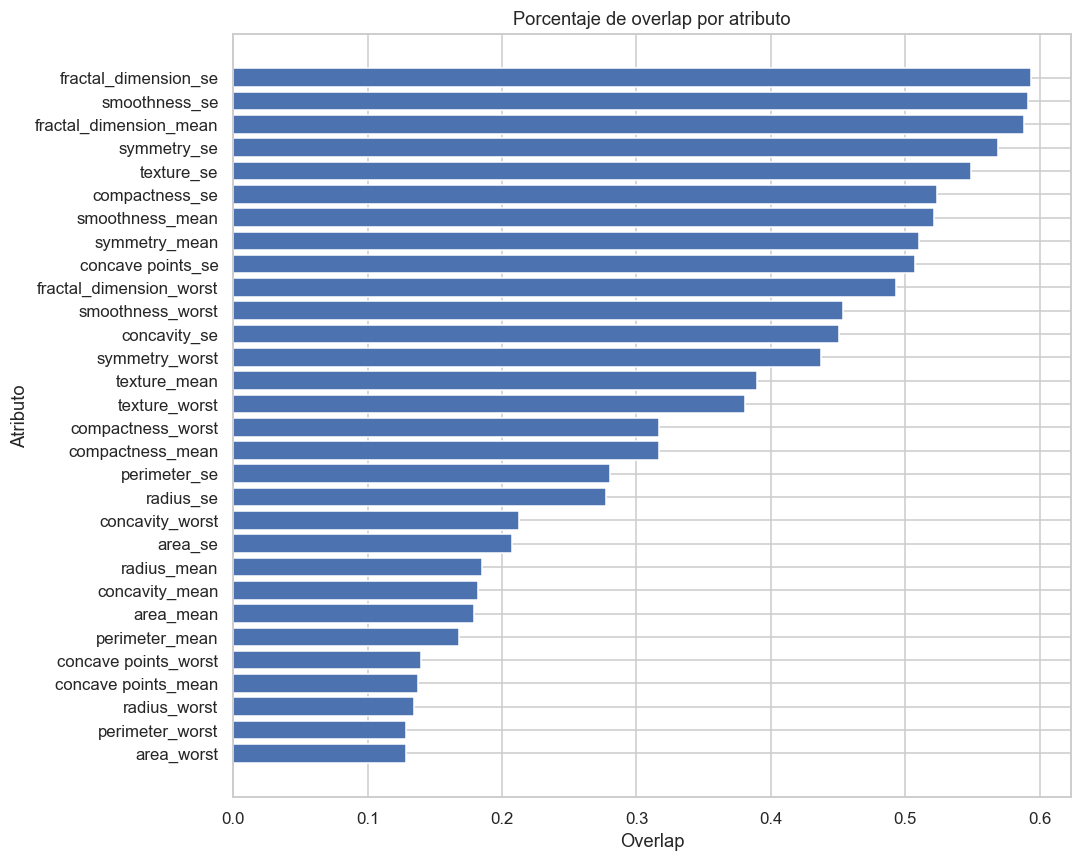

In [9]:
plt.figure(figsize=(10, 8))
ordered_overlap = overlap_df.sort_values('overlap', ascending=True)
plt.barh(ordered_overlap['attribute'], ordered_overlap['overlap'])
plt.title('Porcentaje de overlap por atributo')
plt.xlabel('Overlap')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

## Ejercicio 4: Selección del modelo por `GridSearchCV`

Se divide la muestra en entrenamiento y validación externa. Luego se entrena un `Pipeline` con dos pasos:

1. `StandardScaler`, necesario porque SVM es sensible a la escala de las variables.
2. `SVC(kernel='rbf')`, usando kernel radial para permitir fronteras de decisión no lineales.

La búsqueda de grilla evalúa las combinaciones solicitadas de `C` y `gamma` con validación cruzada de 10 folds.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Tamaño X_train:', X_train.shape)
print('Tamaño X_test :', X_test.shape)
print('\nDistribución y_train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nDistribución y_test:')
print(y_test.value_counts(normalize=True).round(3))

Tamaño X_train: (381, 30)
Tamaño X_test : (188, 30)

Distribución y_train:
diagnosis_bin
0    0.627
1    0.373
Name: proportion, dtype: float64

Distribución y_test:
diagnosis_bin
0    0.628
1    0.372
Name: proportion, dtype: float64


In [11]:
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

param_grid = {
    'svc__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'svc__gamma': [0.0000001, 0.0001, 0.001, 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=10,
    return_train_score=True,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_search.best_params_)
print('Mejor accuracy promedio en CV:', round(grid_search.best_score_, 4))
print('Accuracy del mejor estimador en entrenamiento:', round(grid_search.best_estimator_.score(X_train, y_train), 4))

Mejores hiperparámetros: {'svc__C': 10, 'svc__gamma': 0.01}
Mejor accuracy promedio en CV: 0.9789
Accuracy del mejor estimador en entrenamiento: 0.9895


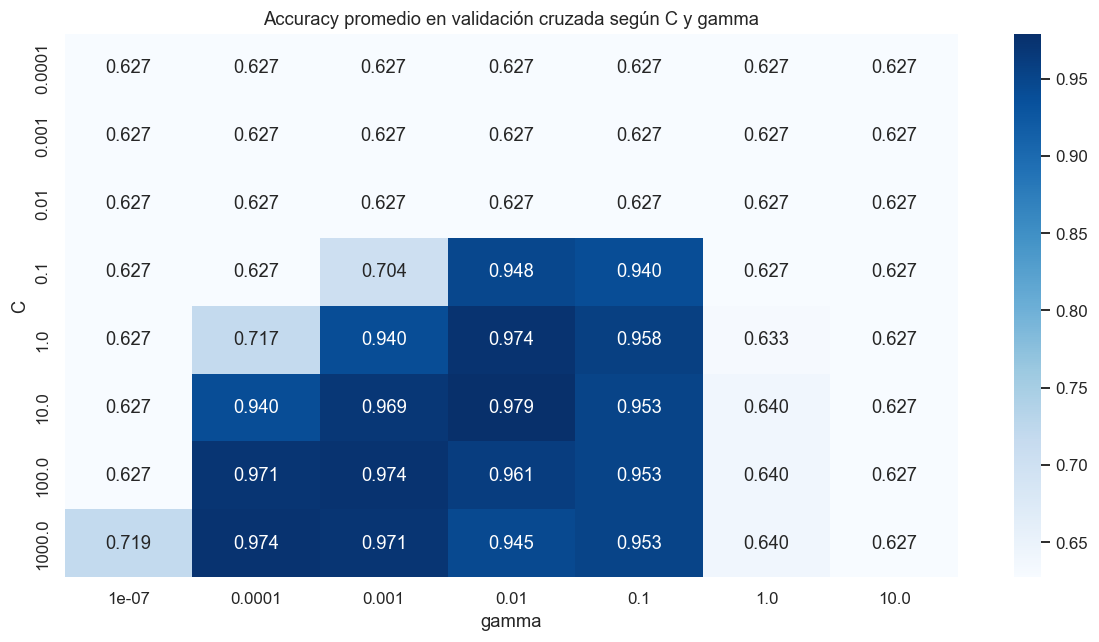

In [12]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['C'] = cv_results['param_svc__C'].astype(float)
cv_results['gamma'] = cv_results['param_svc__gamma'].astype(float)

heatmap_data = cv_results.pivot(index='C', columns='gamma', values='mean_test_score')

plt.figure(figsize=(11, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='Blues')
plt.title('Accuracy promedio en validación cruzada según C y gamma')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

In [13]:
# Rango eficiente: combinaciones con accuracy promedio dentro de 0.005 puntos del mejor score.
efficient_threshold = grid_search.best_score_ - 0.005
efficient_models = cv_results.loc[
    cv_results['mean_test_score'] >= efficient_threshold,
    ['C', 'gamma', 'mean_test_score', 'mean_train_score']
].sort_values('mean_test_score', ascending=False)

print('Umbral usado para definir desempeño eficiente:', round(efficient_threshold, 4))
efficient_models

Umbral usado para definir desempeño eficiente: 0.9739


,C,gamma,mean_test_score,mean_train_score
38,10.0,0.01,0.978947,0.988334


**Reporte de selección del modelo.** La mejor combinación encontrada por validación cruzada fue `C = 10` y `gamma = 0.01`. El desempeño promedio de validación cruzada fue cercano a 0.979, mientras que el desempeño en entrenamiento del mejor estimador fue cercano a 0.990. Esto indica un modelo con muy buen ajuste y sin una brecha excesiva entre entrenamiento y validación cruzada.

Bajo el criterio de desempeño eficiente usado en el notebook, la combinación dominante es `C = 10` y `gamma = 0.01`. Valores demasiado bajos de `C` tienden a subajustar, mientras que valores altos de `gamma` reducen el desempeño porque vuelven la frontera de decisión demasiado sensible al conjunto de entrenamiento.

## Ejercicio 5: Validación del modelo en el hold-out sample

Se evalúa el mejor modelo seleccionado sobre la muestra de validación externa, que no fue usada para estimar los hiperparámetros.

In [14]:
best_svc = grid_search.best_estimator_
y_hat = best_svc.predict(X_test)

print(classification_report(y_test, y_hat, target_names=['Benigno (0)', 'Maligno (1)']))

metrics_holdout = pd.DataFrame({
    'metric': ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    'score': [
        accuracy_score(y_test, y_hat),
        precision_score(y_test, y_hat, average='macro'),
        recall_score(y_test, y_hat, average='macro'),
        f1_score(y_test, y_hat, average='macro')
    ]
})
metrics_holdout

              precision    recall  f1-score   support

 Benigno (0)       0.97      1.00      0.98       118
 Maligno (1)       1.00      0.94      0.97        70

    accuracy                           0.98       188
   macro avg       0.98      0.97      0.98       188
weighted avg       0.98      0.98      0.98       188



,metric,score
0,accuracy,0.978723
1,precision_macro,0.983607
2,recall_macro,0.971429
3,f1_macro,0.976961


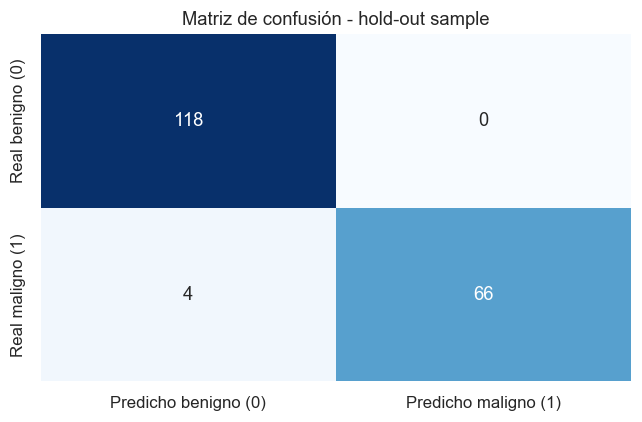

,Predicho benigno (0),Predicho maligno (1)
Real benigno (0),118,0
Real maligno (1),4,66


In [15]:
cm = confusion_matrix(y_test, y_hat)
cm_df = pd.DataFrame(
    cm,
    index=['Real benigno (0)', 'Real maligno (1)'],
    columns=['Predicho benigno (0)', 'Predicho maligno (1)']
)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusión - hold-out sample')
plt.tight_layout()
plt.show()

cm_df

**Comentario sobre desempeño deficiente.** El modelo tiene un desempeño alto en la muestra hold-out, con accuracy aproximado de 0.979. El punto más débil está en la clase maligna: el recall es menor que el de la clase benigna, porque algunos casos malignos fueron clasificados como benignos. Este error es importante en un contexto médico, ya que corresponde a falsos negativos.

## Ejercicio opcional: Depuración de atributos

Se reentrena el modelo usando sólo atributos con overlap menor a 0.45. La idea es conservar variables con menor superposición entre clases y, por lo tanto, con mayor capacidad discriminante individual.

In [16]:
selected_features = overlap_df.loc[overlap_df['overlap'] < 0.45, 'attribute'].tolist()

print('Cantidad de atributos seleccionados:', len(selected_features))
selected_features

Cantidad de atributos seleccionados: 18


['symmetry_worst',
 'texture_mean',
 'texture_worst',
 'compactness_mean',
 'compactness_worst',
 'perimeter_se',
 'radius_se',
 'concavity_worst',
 'area_se',
 'radius_mean',
 'concavity_mean',
 'area_mean',
 'perimeter_mean',
 'concave points_worst',
 'concave points_mean',
 'radius_worst',
 'perimeter_worst',
 'area_worst']

In [17]:
X_selected = df[selected_features]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.33,
    random_state=RANDOM_STATE,
    stratify=y
)

grid_search_selected = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=10,
    return_train_score=True,
    n_jobs=1
)

grid_search_selected.fit(X_train_sel, y_train_sel)

y_hat_selected = grid_search_selected.best_estimator_.predict(X_test_sel)

print('Mejores hiperparámetros con atributos depurados:', grid_search_selected.best_params_)
print('Mejor accuracy promedio CV:', round(grid_search_selected.best_score_, 4))
print('Accuracy entrenamiento:', round(grid_search_selected.best_estimator_.score(X_train_sel, y_train_sel), 4))
print('Accuracy hold-out:', round(accuracy_score(y_test_sel, y_hat_selected), 4))
print('\nReporte de clasificación hold-out:')
print(classification_report(y_test_sel, y_hat_selected, target_names=['Benigno (0)', 'Maligno (1)']))

Mejores hiperparámetros con atributos depurados: {'svc__C': 1000, 'svc__gamma': 0.001}
Mejor accuracy promedio CV: 0.979
Accuracy entrenamiento: 0.9869
Accuracy hold-out: 0.9574

Reporte de clasificación hold-out:
              precision    recall  f1-score   support

 Benigno (0)       0.94      0.99      0.97       118
 Maligno (1)       0.98      0.90      0.94        70

    accuracy                           0.96       188
   macro avg       0.96      0.95      0.95       188
weighted avg       0.96      0.96      0.96       188



In [18]:
comparison = pd.DataFrame({
    'modelo': ['SVC RBF - todos los atributos', 'SVC RBF - overlap < 0.45'],
    'best_C': [grid_search.best_params_['svc__C'], grid_search_selected.best_params_['svc__C']],
    'best_gamma': [grid_search.best_params_['svc__gamma'], grid_search_selected.best_params_['svc__gamma']],
    'cv_accuracy': [grid_search.best_score_, grid_search_selected.best_score_],
    'train_accuracy': [
        grid_search.best_estimator_.score(X_train, y_train),
        grid_search_selected.best_estimator_.score(X_train_sel, y_train_sel)
    ],
    'holdout_accuracy': [
        accuracy_score(y_test, y_hat),
        accuracy_score(y_test_sel, y_hat_selected)
    ],
    'holdout_f1_macro': [
        f1_score(y_test, y_hat, average='macro'),
        f1_score(y_test_sel, y_hat_selected, average='macro')
    ]
})

comparison.to_csv('comparacion_modelos_svm.csv', index=False)
comparison

,modelo,best_C,best_gamma,cv_accuracy,train_accuracy,holdout_accuracy,holdout_f1_macro
0,SVC RBF - todos los atributos,10,0.010,0.978947,0.989501,0.978723,0.976961
1,SVC RBF - overlap < 0.45,1000,0.001,0.979015,0.986877,0.957447,0.953620


**Comentario del modelo depurado.** Al usar sólo atributos con overlap menor a 0.45, el mejor modelo cambia a `C = 1000` y `gamma = 0.001`. Aunque mantiene un muy buen desempeño en validación cruzada, su accuracy hold-out baja respecto del modelo con todos los atributos. Por lo tanto, en esta ejecución el modelo completo es preferible para predicción, mientras que el modelo depurado puede ser útil si se busca una versión más simple e interpretable.

## Conclusión

El clasificador SVM con kernel RBF logra un desempeño alto para la predicción del diagnóstico. La mejor configuración encontrada fue `C = 10` y `gamma = 0.01`, alcanzando un accuracy hold-out aproximado de 0.979. El análisis de overlap muestra que los atributos ligados al tamaño y a la forma del núcleo celular, especialmente medidas `worst`, tienen menor superposición entre clases y son más informativos.

La principal limitación del modelo no está en la exactitud global, sino en los falsos negativos de la clase maligna. En problemas médicos, este tipo de error es crítico, por lo que se recomienda revisar recall, matriz de confusión y eventualmente ajustar el criterio de decisión si el objetivo principal es minimizar falsos negativos.

In [19]:
# Serialización de objetos finales para dejar evidencia reproducible.
with open('svm_breast_cancer_best_model.pkl', 'wb') as file:
    pickle.dump(best_svc, file)

with open('svm_breast_cancer_train_test.pkl', 'wb') as file:
    pickle.dump({
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'features': features,
        'selected_features_overlap_lt_045': selected_features
    }, file)

print('Archivos serializados creados correctamente.')

Archivos serializados creados correctamente.
